In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps
from scipy.signal import find_peaks, convolve, medfilt, savgol_filter
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from scipy.ndimage import median_filter
import matplotlib.animation as animation
import matplotlib as mpl
from glob import glob
from copy import copy
from natsort import natsorted
from pandas import DataFrame
import sys
import pickle
import pandas as pd
import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '../..'))
sys.path.insert(0, parent_dir)
import matplotlibcolors
plt.style.use(parent_dir + '/matplotlibrc')
from KID_S21 import loop_over_S21_files


%matplotlib widget

In [2]:
with open('LT402chip4_master.pkl', 'rb') as f:
    master = pickle.load(f)

FileNotFoundError: [Errno 2] No such file or directory: 'LT402chip4_master.pkl'

In [6]:
dir = r'Z:\KIDonSun\experiments\Entropy ADR/'
chips = ['LT419W1witness_BF_20260324_mapping']
paths = []
for chip in chips:
    paths.append(dir + chip + '/S21/Power/')
paths
    

['Z:\\KIDonSun\\experiments\\Entropy ADR/LT419W1witness_BF_20260324_mapping/S21/Power/']

In [7]:
for i, path in enumerate(paths):
    df = loop_over_S21_files(path, kid=None, pread=110, plot=False, model='khalilswensonbias', method='least_squares')
    with open(chips[i] + '_Qs.pkl', 'wb') as f:
        pickle.dump(df, f)


c:\Users\wilbertr\ownCloud2\PhD\PhD\PythonProjects\spatial-mapping\KID_S21.py:53: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_results = pd.concat([df_results, new_entry], ignore_index=True)


In [8]:
df

,KID,Power,Temperature,f0,f0_std,Ql,Ql_std,Qc,Qc_std,Qi,Qi_std,Pint,redchisqr,phi,a_nonlin,a_nonlin_std,dw,dw_std
0,1,-110.0,0.129979,2.173046,1.531091e-07,40791.349447,58.671661,43321.109107,92.696354,698535.330553,23083.115723,-69.127133,0.000006,0.036943,0.204133,0.002728,9.844665e-07,3.240634e-08
1,2,-110.0,0.130002,2.275776,1.490515e-07,34730.274920,41.266334,36940.016157,67.972501,580582.420827,15628.649716,-69.832305,0.000005,-0.147501,0.157228,0.002136,-4.868003e-06,3.311070e-08
2,3,-110.0,0.130002,2.315488,1.572838e-07,31236.629994,38.622247,32931.771405,73.165654,606838.787446,22147.967831,-70.254366,0.000005,-0.304238,0.164149,0.001994,-1.163747e-05,4.122546e-08
3,4,-110.0,0.129994,2.344304,1.319738e-07,37800.896078,45.935761,40052.176192,77.520269,672509.893799,19617.561172,-69.447718,0.000004,-0.179144,0.250038,0.001942,-5.615209e-06,2.969395e-08
4,5,-110.0,0.130037,2.376652,1.286314e-07,38173.986262,39.361450,40478.717623,64.454198,670461.658472,16681.074714,-69.408416,0.000004,0.187958,0.190939,0.002014,5.920867e-06,2.910805e-08
5,6,-110.0,0.129995,2.403965,1.359394e-07,44221.391695,67.791813,47638.265205,125.201742,616537.421952,18213.734521,-68.838410,0.000006,-0.346477,0.215392,0.002377,-9.813465e-06,3.663235e-08
6,7,-110.0,0.129948,2.427134,1.509519e-07,33141.577464,38.025767,35224.907384,66.309434,560357.236387,15045.146392,-70.032534,0.000005,-0.254167,0.150893,0.001940,-9.512714e-06,3.663098e-08
7,8,-110.0,0.130014,2.504770,1.541872e-07,29565.627817,30.541789,31714.602280,52.455549,436330.046588,8440.702773,-70.568349,0.000005,0.399168,0.108960,0.001870,1.786778e-05,4.377673e-08
8,9,-110.0,0.129969,2.513103,1.752037e-07,27174.444975,23.895238,28425.132140,41.418841,617610.231166,19055.791049,-70.825310,0.000004,0.008853,0.129946,0.001756,4.093954e-07,3.871405e-08
9,10,-110.0,0.130009,2.565596,1.187223e-07,44995.995377,48.511695,47873.999144,78.824807,748483.469285,17802.554183,-68.709019,0.000004,0.226281,0.230871,0.002057,6.563496e-06,2.733759e-08


In [9]:
dfs = []
for chip in chips:
    with open(chip + '_Qs.pkl', 'rb') as f:
        df = pickle.load(f) 
        dfs.append(df)

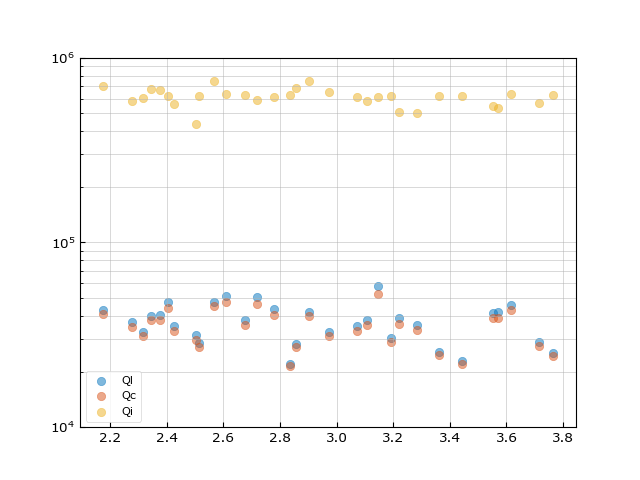

In [10]:
Q = 50e3
min_fwhm = 3
dfs_filtered = []   
fig, ax = plt.subplots(1, 1)
for i, df in enumerate(dfs):

    f0 = df['f0']
    Ql = df['Ql']
    Qi = df['Qi']
    Qc = df['Qc']
    a = df['a_nonlin']
    dw = df['dw']

    df0s = (np.asarray(f0)[1:] - np.asarray(f0)[:-1]) * Q / np.asarray(f0)[:-1]
    too_close = df0s < min_fwhm
    too_close_mask = np.hstack((False, too_close)) + np.hstack((too_close, False))
    Qi_mask = (Qi > 0) & (Qi < 1e7)
    Qc_mask = (Qc > 0) & (Qc < 1e6)
    nonlin_mask = (a >= 0) & (a < 0.7)
    mask = Qi_mask & Qc_mask & nonlin_mask & ~too_close_mask
    dfs_filtered.append(df[mask])
    ax.scatter(f0[mask], Qc[mask], alpha=0.5, label='Ql')
    ax.scatter(f0[mask], Ql[mask], alpha=0.5, label='Qc')
    ax.scatter(f0[mask], Qi[mask], alpha=0.5, label='Qi')
    ax.set_yscale('log') 
    ax.set_ylim(1e4, 1e6)   
    ax.legend()

In [6]:
labels = ['trimmeasured']
for i, df_filtered in enumerate(dfs_filtered):
    label = labels[i]
    f0_map = master[label]['f0']
    f0_fit = df_filtered['f0']
    ids = []
    for f0 in f0_fit:
        id = np.nanargmin(np.abs(f0_map - f0))
        ids.append(id)
    
    keys = ['Ql', 'Qc', 'Qi', 'a_nonlin', 'dw']
    for key in keys:
        master[label][key] = np.empty(f0_map.shape)
        master[label][key][:] = np.nan
        master[label][key][ids] = df_filtered[key]
print(np.sum(Qc_mask), np.sum(Qi_mask), np.sum(nonlin_mask), np.sum(~too_close_mask))    

NameError: name 'Qc_mask' is not defined

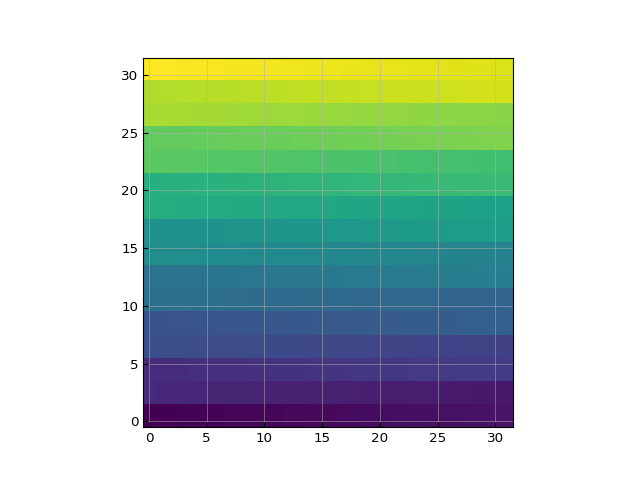

In [8]:
rows = master['design']['row'].astype(int)
cols = master['design']['col'].astype(int)
M = np.amax(rows) + 1
N = np.amax(cols) + 1
map = np.ones((M, N), dtype=int)
map[rows, cols] = np.arange(int(M*N))
r = []
for i, row in enumerate(rows):
    col = cols[i]
    if row // 2 % 2 == 0:
        r.append((row // 2) * (N+5) + col)
    elif row // 2 % 2 == 1:
        r.append((row // 2) * (N+5) + (N-col))
r = np.array(r).astype(float)
fig, ax = plt.subplots()
ax.imshow(r[map], origin='lower', cmap='viridis')

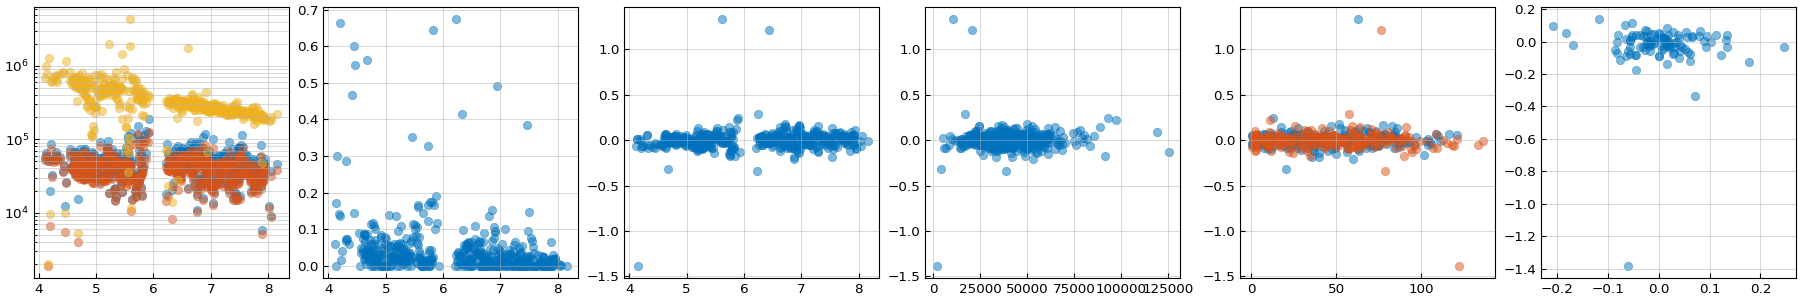

In [9]:

fig, axes = plt.subplot_mosaic('abcdef', figsize=(18, 3), constrained_layout=True)
fm = master['trimmeasured']['f0']
fd = master['trimdesign']['f0']
Qc = master['trimmeasured']['Qc']
Ql = master['trimmeasured']['Ql']
Qi = master['trimmeasured']['Qi']
a = master['trimmeasured']['a_nonlin']
dw = master[label]['dw']
ax = axes['a']
ax.scatter(fm[~too_close_mask], Qc[~too_close_mask], alpha=0.5)
ax.scatter(fm[~too_close_mask], Ql[~too_close_mask], alpha=0.5)
ax.scatter(fm[~too_close_mask], Qi[~too_close_mask], alpha=0.5)
ax.set_yscale('log')
ax = axes['b']
ax.scatter(fm[~too_close_mask], a[~too_close_mask], alpha=0.5)
ax = axes['c']
phi = np.arctan(2*Ql*dw/(2*np.pi*fm))
ax.scatter(fm[~too_close_mask], phi[~too_close_mask], alpha=0.5)
ax = axes['d']
ax.scatter(Ql[~too_close_mask], phi[~too_close_mask], alpha=0.5)
ax = axes['e']
odd_mask = np.zeros(M*N, dtype=bool)
odd_mask[map[1::2, :].flatten()] = True
even_mask = np.zeros(M*N, dtype=bool)
even_mask[map[::2, :].flatten()] = True
ax.scatter(r[~too_close_mask & odd_mask]/fm[~too_close_mask & odd_mask], phi[~too_close_mask & odd_mask], alpha=0.5)
ax.scatter(r[~too_close_mask & even_mask]/fm[~too_close_mask & even_mask], phi[~too_close_mask & even_mask], alpha=0.5)
ax = axes['f']
odd_mask = (rows % 2 == 1)
even_mask = (rows % 2 == 0)
nan_mask = np.isnan(phi) | too_close_mask
ys = rows[nan_mask]
xs = cols[nan_mask]
for x, y in zip(xs, ys):
    if y % 2 == 0:
        nan_mask[(rows == y+1) & (cols == x)] = True
    elif y % 2 == 1:
        nan_mask[(rows == y-1) & (cols == x)] = True
ax.scatter(phi[~nan_mask & odd_mask], phi[~nan_mask & even_mask], alpha=0.5)

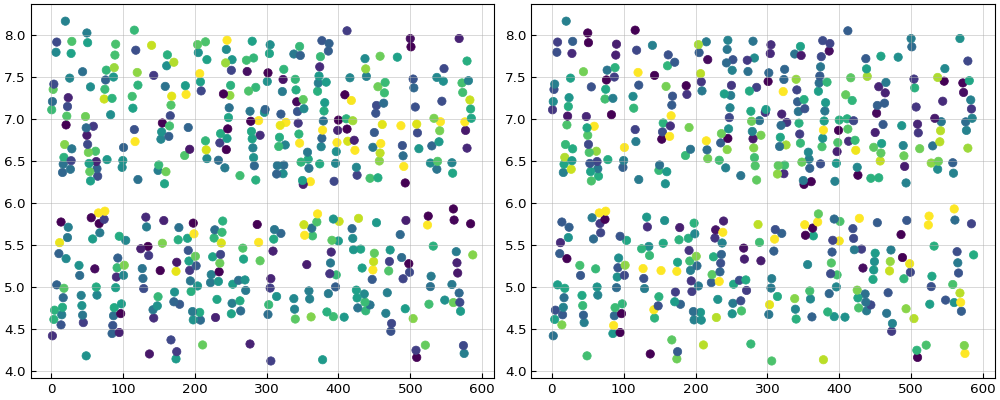

In [10]:
fig, axes = plt.subplot_mosaic('ab', figsize=(10, 4), constrained_layout=True)
ax = axes['a']
ax.scatter(r[~too_close_mask], fm[~too_close_mask], c=phi[~too_close_mask], cmap='viridis', vmin=np.nanpercentile(phi, 5), vmax=np.nanpercentile(phi, 95))
ax = axes['b']
ax.scatter(r[~too_close_mask], fm[~too_close_mask], c=Ql[~too_close_mask], cmap='viridis', vmin=np.nanpercentile(Ql, 5), vmax=np.nanpercentile(Ql, 95))

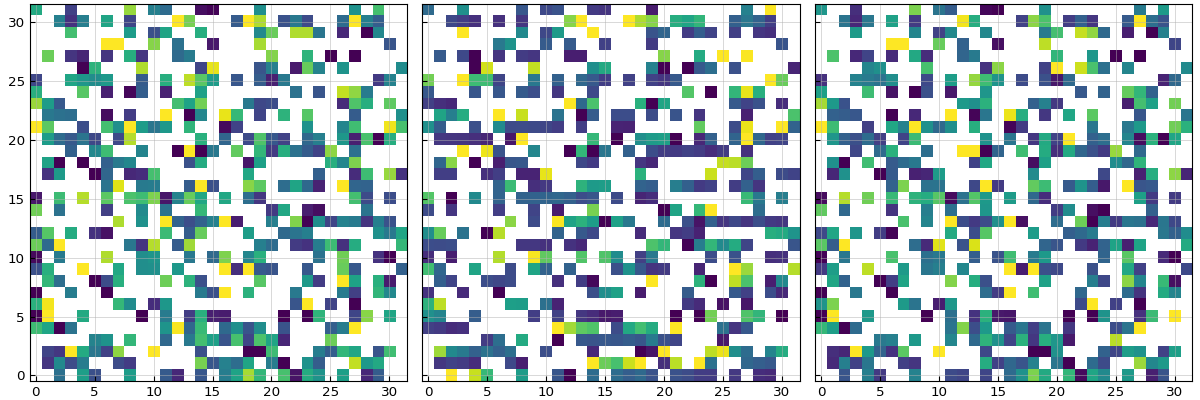

In [11]:

fig, axes = plt.subplot_mosaic('abc', figsize=(12,4), sharey=True, constrained_layout=True) 
keys = ['Ql', 'Qi', 'Qc']
for i, ax in enumerate(axes):
    key = keys[i]
    Q = master['trimmeasured'][key]
    Q[too_close_mask] = np.nan
    Q_map = Q[map]
    # Q_map = median_filter(Q_map, size=(1,3))
    axes[ax].imshow(Q_map, origin='lower', cmap='viridis', vmin=np.nanpercentile(Q, 5), vmax=np.nanpercentile(Q, 95))

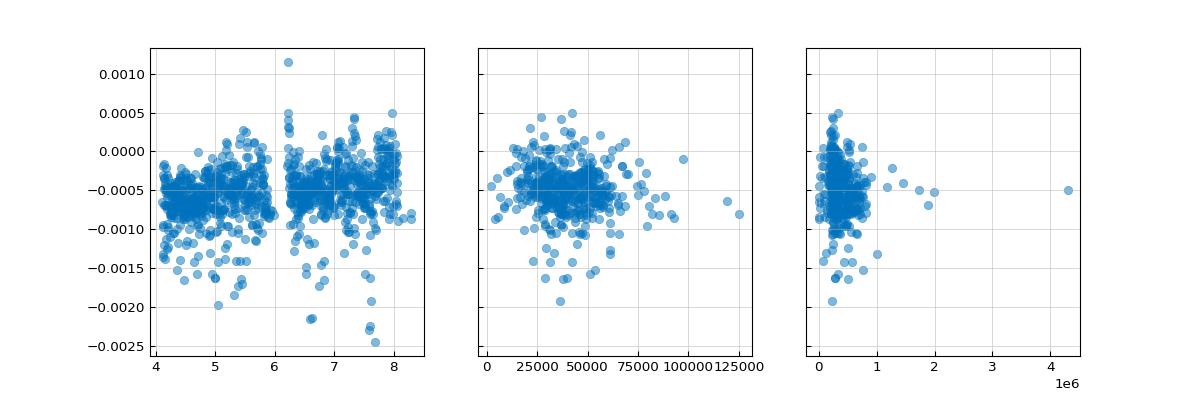

In [12]:
fig, axes = plt.subplot_mosaic('abc', figsize=(12,4), sharey=True)
ax = axes['a']
df_f = (fm - fd) / fd
ax.scatter(fm, df_f, alpha=0.5)
ax = axes['b']
ax.scatter(Ql[~too_close_mask], df_f[~too_close_mask], alpha=0.5)
ax = axes['c']
ax.scatter(Qi[~too_close_mask], df_f[~too_close_mask], alpha=0.5)

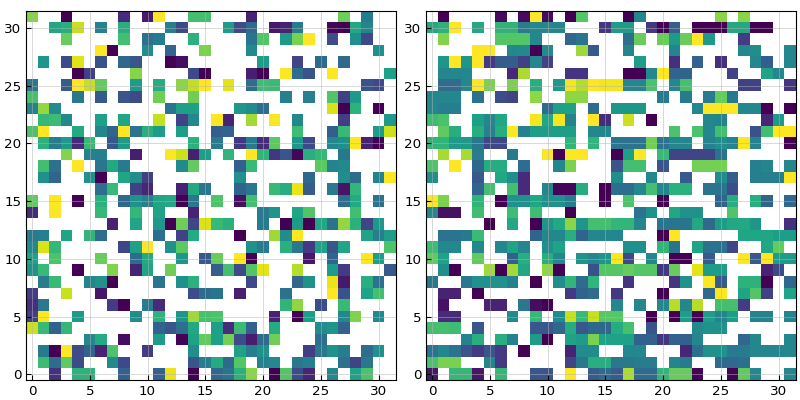

In [13]:
map = np.ones((32,32), dtype=int)
map[master['design']['row'].astype(int), master['design']['col'].astype(int)] = np.arange(1024)
fig, axes = plt.subplot_mosaic('ab', figsize=(8,4), constrained_layout=True)
ax = axes['a']
dw = master[label]['dw']
Q =  master[label]['Ql']
phi = np.arctan(2*Q*dw/(2*np.pi*master[label]['f0']))
phi[too_close_mask] = np.nan
dw_map = phi[map]
im = ax.imshow(dw_map, cmap='viridis', origin='lower', vmin=np.nanpercentile(dw_map, 5), vmax=np.nanpercentile(dw_map, 95))

phi[too_close_mask] = 0
dw_map = phi[map]
dw_filtered = median_filter(dw_map, size=(1,5))
axes['b'].imshow(dw_filtered, cmap='viridis', origin='lower', vmin=np.nanpercentile(dw_filtered, 5), vmax=np.nanpercentile(dw_filtered, 95))